In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gc

In [ ]:
pip install scikit-optimize

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

# **GA_SESSIONS**

In [ ]:
df_session = pd.read_csv('ga_sessions.csv')

C:\Users\ELwVwIR\AppData\Local\Temp\ipykernel_12448\1859674011.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_session = pd.read_csv('ga_sessions.csv')


In [ ]:
duplicates_count = df_session['session_id'].value_counts()
duplicated_values = duplicates_count[duplicates_count > 1]

print(duplicated_values)

Series([], Name: count, dtype: int64)


In [ ]:
df_session['session_id'].nunique()

1860042

In [ ]:
df_session.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [ ]:
df_session.shape

(1860042, 18)

In [ ]:
df_session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


## **Анализ пропусков**

In [ ]:
missing_count = df_session.isnull().sum()
missing_count=missing_count[missing_count>0]

missing_df = pd.DataFrame({
  'Пропусков': missing_count,
  'Процент':(missing_count/len(df_session)*100).round(1)
})

missing_df.sort_values('Процент', ascending=False)

,Пропусков,Процент
device_model,1843704,99.1
utm_keyword,1082061,58.2
device_os,1070138,57.5
device_brand,367178,19.7
utm_adcontent,335615,18.0
utm_campaign,219603,11.8
utm_source,97,0.0


In [ ]:
df_session['utm_keyword'].value_counts()

utm_keyword
puhZPIYqKXeFPaUviSjo    506819
aXQzDWsJuGXeBXexNHjc     24241
pHqgLcdBQPSLcrTpLkdr     13767
ITfrGJNwVsHBGJMAKoct     13353
hAmNSZmQkKQKAjZEGlgb     11297
                         ...  
ziplOmogOIgMoedLNvaR         1
hIlpdXTVGwzYWIOqvhtN         1
DWdObWJnYkxegWsWkVuy         1
KoBBKFfLGZzJWZoFqBZs         1
lzplajwQRAqxjcDrOuBZ         1
Name: count, Length: 1219, dtype: int64

In [ ]:
df_session['device_os'].value_counts()

device_os
Android          464054
iOS              207104
Windows           88307
Macintosh         24824
Linux              5120
(not set)           364
Chrome OS            83
BlackBerry           27
Tizen                 7
Samsung               4
Windows Phone         4
Firefox OS            3
Nokia                 3
Name: count, dtype: int64

In [ ]:
df_session['device_brand'].value_counts()

device_brand
Apple      551088
Samsung    332194
Xiaomi     288367
Huawei     185853
Realme      19058
            ...  
Maze            1
Tagital         1
FREETEL         1
Maxvi           1
Opera           1
Name: count, Length: 205, dtype: int64

In [ ]:
df_session['utm_adcontent'].value_counts()

utm_adcontent
JNHcPlZPxEMWDnRiyoBf    1006599
vCIpmpaGBnIQhyYNkXqp     181048
xhoenQgDQsgfEPYNPwKO     113072
PkybGvWbaqORmxjNunqZ      60316
LLfCasrxQzJIyuldcuWy      24222
                         ...   
vxMugcyrQNIxwvOkqILt          1
cQRpDybanXRyHUvzJmgo          1
wDodCPywICvJWGwjXgTp          1
IcLcclbnECGqvCQgOdET          1
oJivRDNIrrOckRBIKOtG          1
Name: count, Length: 286, dtype: int64

In [ ]:
df_session['utm_source'].value_counts()

utm_source
ZpYIoDJMcFzVoPFsHGJL    578290
fDLlAcSmythWSCVMvqvL    300575
kjsLglQLzykiRbcDiGcD    266354
MvfHsxITijuriZxsqZqt    186199
BHcvLfOaCWvWTykYqHVe    116320
                         ...  
bZGRDuESNKqbvzmxXlpf         1
jCIRaffxlokbeWIRXHKg         1
tasNSXvMCFllwbrJviyg         1
SHJidRpqXditMCUeEFzb         1
EiQppLFrUZrUsjXVulLg         1
Name: count, Length: 293, dtype: int64

Заполнение пропусков рекламных признаков

In [ ]:
import pandas as pd

def fill_using_mode(df_session, target_col, group_cols):
    """
    Заполняет пропуски в target_col, используя моду по group_cols.
    """
    known = df_session[df_session[target_col].notna()].copy()

    # Вычисляем моду для каждой группы
    mode_series = known.groupby(group_cols)[target_col].agg(
        lambda x: x.mode()[0] if not x.mode().empty else None
    )

    missing_mask = df_session[target_col].isna()
    if missing_mask.any():
        missing_data = df_session.loc[missing_mask, group_cols].copy()
        df_session.loc[missing_mask, target_col] = missing_data.apply(
            lambda row: mode_series.get(tuple(row), None), axis=1
        )

    return df_session

In [ ]:
group_base = ['utm_source', 'utm_medium']

# 1. Заполняем utm_campaign
fill_using_mode(df_session, 'utm_campaign', group_base)

# 2. Заполняем utm_adcontent (теперь используем и utm_campaign)
fill_using_mode(df_session, 'utm_adcontent', group_base + ['utm_campaign'])

# 3. Заполняем utm_keyword (используем все доступные)
fill_using_mode(df_session, 'utm_keyword', group_base + ['utm_campaign', 'utm_adcontent'])


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,XHNUiSKKGTEpSAlaVMFQ,NOBKLgtuvqYWkXQHeYWM,None,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,XHNUiSKKGTEpSAlaVMFQ,JNHcPlZPxEMWDnRiyoBf,hAmNSZmQkKQKAjZEGlgb,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1860037,9055415581448263752.1640159305.1640159305,2108378238.164016,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,jvsVVQVKRfBIqBDBuCkq,JNHcPlZPxEMWDnRiyoBf,VlqBmecIOXWjCWUmQkLd,desktop,Windows,NaN,NaN,1920x1080,Chrome,Russia,Moscow
1860038,9055421130527858185.1622007305.1622007305,2108379530.162201,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,NaN,Apple,NaN,390x844,Safari,Russia,Stavropol
1860039,9055422955903931195.1636979515.1636979515,2108379955.163697,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,NaN,375x667,Safari,Russia,Moscow
1860040,905543020766873816.1638189404.1638189404,210838164.163819,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,NaN,393x851,Chrome,Russia,Chelyabinsk


In [ ]:
missing_count = df_session.isnull().sum()
missing_count=missing_count[missing_count>0]

missing_df = pd.DataFrame({
  'Пропусков': missing_count,
  'Процент':(missing_count/len(df_session)*100).round(1)
})

missing_df.sort_values('Процент', ascending=False)

,Пропусков,Процент
device_model,1843704,99.1
device_os,1070138,57.5
device_brand,367178,19.7
utm_keyword,87061,4.7
utm_adcontent,51140,2.7
utm_campaign,8844,0.5
utm_source,97,0.0


Восстановление признаков устройств

In [ ]:
group_brand = [
    'device_category',
    'device_browser',
    'geo_city'
]

fill_using_mode(df_session, 'device_brand', group_brand)

group_os = group_brand + ['device_brand']
fill_using_mode(df_session, 'device_os', group_os)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,XHNUiSKKGTEpSAlaVMFQ,NOBKLgtuvqYWkXQHeYWM,None,mobile,Android,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,XHNUiSKKGTEpSAlaVMFQ,JNHcPlZPxEMWDnRiyoBf,hAmNSZmQkKQKAjZEGlgb,mobile,Android,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1860037,9055415581448263752.1640159305.1640159305,2108378238.164016,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,jvsVVQVKRfBIqBDBuCkq,JNHcPlZPxEMWDnRiyoBf,VlqBmecIOXWjCWUmQkLd,desktop,Windows,Huawei,NaN,1920x1080,Chrome,Russia,Moscow
1860038,9055421130527858185.1622007305.1622007305,2108379530.162201,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,NaN,390x844,Safari,Russia,Stavropol
1860039,9055422955903931195.1636979515.1636979515,2108379955.163697,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,NaN,375x667,Safari,Russia,Moscow
1860040,905543020766873816.1638189404.1638189404,210838164.163819,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,NaN,393x851,Chrome,Russia,Chelyabinsk


In [ ]:
missing_count = df_session.isnull().sum()
missing_count=missing_count[missing_count>0]

missing_df = pd.DataFrame({
  'Пропусков': missing_count,
  'Процент':(missing_count/len(df_session)*100).round(1)
})

missing_df.sort_values('Процент', ascending=False)

,Пропусков,Процент
device_model,1843704,99.1
device_brand,137997,7.4
device_os,105822,5.7
utm_keyword,87061,4.7
utm_adcontent,51140,2.7
utm_campaign,8844,0.5
utm_source,97,0.0


Для востановления device_model требуется база знаний о том какое разрешение экрана у какого производителя на каком устройстве используется. Это труднозатратно, поэтому этот признак мы удалим.

Но возможно по нему мы смогли бы предсказывать состоятельность людей, по которой могли бы предсказывать event_action.

## *Категориальные данные*

In [ ]:
df_session['device_category'].value_counts()

device_category
mobile     1474871
desktop     366863
tablet       18308
Name: count, dtype: int64

In [ ]:
df_session['visit_datetime'] = pd.to_datetime(df_session['visit_date'] + ' ' + df_session['visit_time'])

# 2. Извлекаем нужные компоненты и создаём новые колонки
df_session['sess_year'] = df_session['visit_datetime'].dt.year
df_session['sess_month'] = df_session['visit_datetime'].dt.month
df_session['sess_day'] = df_session['visit_datetime'].dt.day
df_session['sess_hour'] = df_session['visit_datetime'].dt.hour
df_session['sess_minute'] = df_session['visit_datetime'].dt.minute
df_session['sess_second'] = df_session['visit_datetime'].dt.second
df_session['sess_weekday'] = df_session['visit_datetime'].dt.weekday  # 0 = понедельник, 6 = воскресенье
df_session['sess_quarter'] = df_session['visit_datetime'].dt.quarter  # квартал (1–4)
df_session['sess_dayofyear'] = df_session['visit_datetime'].dt.dayofyear  # день года (1–366)

df_session.drop(columns=['visit_date', 'visit_time', 'visit_datetime'], inplace=True)

In [ ]:
df_session.shape

(1860042, 25)

In [ ]:
print(df_session['session_id'].duplicated().sum())

0


In [ ]:
df_session.T.head(25)

,0,1,2,3,4,5,6,7,8,9,...,1860032,1860033,1860034,1860035,1860036,1860037,1860038,1860039,1860040,1860041
session_id,9055434745589932991.1637753792.1637753792,905544597018549464.1636867290.1636867290,9055446045651783499.1640648526.1640648526,9055447046360770272.1622255328.1622255328,9055447046360770272.1622255345.1622255345,9055447192389856083.1622453074.1622453074,9055455318486370642.1640843788.1640843788,9055461992850812764.1626107740.1626107740,9055462349345527315.1638536723.1638536723,9055466554104774132.1624800757.1624800757,...,9055394269810294140.1629912447.1629912447,9055394342833425189.1638599463.1638599463,9055397194683347295.1630237022.1630237022,9055398929844789828.1624891784.1624891784,9055401700113249881.1639446112.1639446112,9055415581448263752.1640159305.1640159305,9055421130527858185.1622007305.1622007305,9055422955903931195.1636979515.1636979515,905543020766873816.1638189404.1638189404,9055430416266113553.1640968742.1640968742
client_id,2108382700.163776,210838531.163687,2108385331.164065,2108385564.162225,2108385564.162225,2108385598.162245,2108387490.164084,2108389044.162611,2108389127.163854,2108390106.16248,...,2108373276.162991,2108373293.16386,2108373957.163024,2108374361.162489,2108375006.163945,2108378238.164016,2108379530.162201,2108379955.163697,210838164.163819,2108381692.164097
visit_number,1,1,1,1,2,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
utm_source,ZpYIoDJMcFzVoPFsHGJL,MvfHsxITijuriZxsqZqt,ZpYIoDJMcFzVoPFsHGJL,kjsLglQLzykiRbcDiGcD,kjsLglQLzykiRbcDiGcD,kjsLglQLzykiRbcDiGcD,TxKUcPpthBDPieTGmVhx,ZpYIoDJMcFzVoPFsHGJL,ZpYIoDJMcFzVoPFsHGJL,ZpYIoDJMcFzVoPFsHGJL,...,bByPQxmDaMXgpHeypKSM,ZpYIoDJMcFzVoPFsHGJL,ISrKoXQCxqqYvAZICvjs,kjsLglQLzykiRbcDiGcD,ZpYIoDJMcFzVoPFsHGJL,BHcvLfOaCWvWTykYqHVe,fDLlAcSmythWSCVMvqvL,fDLlAcSmythWSCVMvqvL,ZpYIoDJMcFzVoPFsHGJL,fgymSoTvjKPEgaIJqsiH
utm_medium,banner,cpm,banner,cpc,cpc,organic,cpc,banner,banner,banner,...,referral,banner,blogger_stories,cpc,banner,cpc,(none),(none),banner,cpm
utm_campaign,LEoPHuyFvzoNfnzGgfcd,FTjNLDyTrXaWYgZymFkV,LEoPHuyFvzoNfnzGgfcd,XHNUiSKKGTEpSAlaVMFQ,XHNUiSKKGTEpSAlaVMFQ,LTuZkdKfxRGVceoWkVyg,FTjNLDyTrXaWYgZymFkV,LEoPHuyFvzoNfnzGgfcd,LEoPHuyFvzoNfnzGgfcd,LEoPHuyFvzoNfnzGgfcd,...,LTuZkdKfxRGVceoWkVyg,LEoPHuyFvzoNfnzGgfcd,zfwIehuEfWYdYrEZgRLo,vXsFkagGabkcWKlgLzSg,TmThBvoCcwkCZZUWACYq,jvsVVQVKRfBIqBDBuCkq,LTuZkdKfxRGVceoWkVyg,LTuZkdKfxRGVceoWkVyg,LEoPHuyFvzoNfnzGgfcd,FTjNLDyTrXaWYgZymFkV
utm_adcontent,vCIpmpaGBnIQhyYNkXqp,xhoenQgDQsgfEPYNPwKO,vCIpmpaGBnIQhyYNkXqp,NOBKLgtuvqYWkXQHeYWM,JNHcPlZPxEMWDnRiyoBf,JNHcPlZPxEMWDnRiyoBf,LcGIUNPUAmXtQJaDfFBR,JNHcPlZPxEMWDnRiyoBf,vCIpmpaGBnIQhyYNkXqp,JNHcPlZPxEMWDnRiyoBf,...,JNHcPlZPxEMWDnRiyoBf,vCIpmpaGBnIQhyYNkXqp,JNHcPlZPxEMWDnRiyoBf,JNHcPlZPxEMWDnRiyoBf,JNHcPlZPxEMWDnRiyoBf,JNHcPlZPxEMWDnRiyoBf,JNHcPlZPxEMWDnRiyoBf,JNHcPlZPxEMWDnRiyoBf,JNHcPlZPxEMWDnRiyoBf,yYdBRbPmBMUZHXwqGxNx
utm_keyword,puhZPIYqKXeFPaUviSjo,IGUCNvHlhfHpROGclCit,puhZPIYqKXeFPaUviSjo,None,hAmNSZmQkKQKAjZEGlgb,UKNBOHebRIIsQRsjNKay,PwscUHjoUJDrtfWESIHj,puhZPIYqKXeFPaUviSjo,puhZPIYqKXeFPaUviSjo,puhZPIYqKXeFPaUviSjo,...,puhZPIYqKXeFPaUviSjo,puhZPIYqKXeFPaUviSjo,puhZPIYqKXeFPaUviSjo,None,puhZPIYqKXeFPaUviSjo,VlqBmecIOXWjCWUmQkLd,puhZPIYqKXeFPaUviSjo,puhZPIYqKXeFPaUviSjo,puhZPIYqKXeFPaUviSjo,oKjXDUsycmahkgMhGdAR
device_category,mobile,mobile,mobile,mobile,mobile,mobile,tablet,mobile,mobile,mobile,...,mobile,mobile,mobile,mobile,mobile,desktop,mobile,mobile,mobile,desktop
device_os,Android,Android,Android,Android,Android,iOS,Android,Android,iOS,Android,...,Android,Android,iOS,Android,Android,Windows,iOS,iOS,Android,Linux


In [ ]:
df_session.head(10)

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,...,geo_city,sess_year,sess_month,sess_day,sess_hour,sess_minute,sess_second,sess_weekday,sess_quarter,sess_dayofyear
0,9055434745589932991.1637753792.1637753792,2108382700.163776,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,...,Zlatoust,2021,11,24,14,36,32,2,4,328
1,905544597018549464.1636867290.1636867290,210838531.163687,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,...,Moscow,2021,11,14,8,21,30,6,4,318
2,9055446045651783499.1640648526.1640648526,2108385331.164065,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,...,Krasnoyarsk,2021,12,28,2,42,6,1,4,362
3,9055447046360770272.1622255328.1622255328,2108385564.162225,1,kjsLglQLzykiRbcDiGcD,cpc,XHNUiSKKGTEpSAlaVMFQ,NOBKLgtuvqYWkXQHeYWM,None,mobile,Android,...,Moscow,2021,5,29,5,0,0,5,2,149
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2,kjsLglQLzykiRbcDiGcD,cpc,XHNUiSKKGTEpSAlaVMFQ,JNHcPlZPxEMWDnRiyoBf,hAmNSZmQkKQKAjZEGlgb,mobile,Android,...,Moscow,2021,5,29,5,0,0,5,2,149
5,9055447192389856083.1622453074.1622453074,2108385598.162245,1,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,UKNBOHebRIIsQRsjNKay,mobile,iOS,...,Saint Petersburg,2021,5,31,12,0,0,0,2,151
6,9055455318486370642.1640843788.1640843788,2108387490.164084,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,LcGIUNPUAmXtQJaDfFBR,PwscUHjoUJDrtfWESIHj,tablet,Android,...,Saint Petersburg,2021,12,30,8,56,28,3,4,364
7,9055461992850812764.1626107740.1626107740,2108389044.162611,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,...,Saint Petersburg,2021,7,12,19,0,0,0,3,193
8,9055462349345527315.1638536723.1638536723,2108389127.163854,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,iOS,...,Moscow,2021,12,3,16,5,23,4,4,337
9,9055466554104774132.1624800757.1624800757,2108390106.16248,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,...,Moscow,2021,6,27,16,0,0,6,2,178


In [ ]:
df_session.shape

(1860042, 25)

In [ ]:
df_session.head()

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,...,geo_city,sess_year,sess_month,sess_day,sess_hour,sess_minute,sess_second,sess_weekday,sess_quarter,sess_dayofyear
0,9055434745589932991.1637753792.1637753792,2108382700.163776,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,...,Zlatoust,2021,11,24,14,36,32,2,4,328
1,905544597018549464.1636867290.1636867290,210838531.163687,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,...,Moscow,2021,11,14,8,21,30,6,4,318
2,9055446045651783499.1640648526.1640648526,2108385331.164065,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,...,Krasnoyarsk,2021,12,28,2,42,6,1,4,362
3,9055447046360770272.1622255328.1622255328,2108385564.162225,1,kjsLglQLzykiRbcDiGcD,cpc,XHNUiSKKGTEpSAlaVMFQ,NOBKLgtuvqYWkXQHeYWM,None,mobile,Android,...,Moscow,2021,5,29,5,0,0,5,2,149
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2,kjsLglQLzykiRbcDiGcD,cpc,XHNUiSKKGTEpSAlaVMFQ,JNHcPlZPxEMWDnRiyoBf,hAmNSZmQkKQKAjZEGlgb,mobile,Android,...,Moscow,2021,5,29,5,0,0,5,2,149


In [ ]:
df_session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 25 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_number              int64 
 3   utm_source                object
 4   utm_medium                object
 5   utm_campaign              object
 6   utm_adcontent             object
 7   utm_keyword               object
 8   device_category           object
 9   device_os                 object
 10  device_brand              object
 11  device_model              object
 12  device_screen_resolution  object
 13  device_browser            object
 14  geo_country               object
 15  geo_city                  object
 16  sess_year                 int32 
 17  sess_month                int32 
 18  sess_day                  int32 
 19  sess_hour                 int32 
 20  sess_minute               int32 
 21  sess_sec

In [ ]:
df_session['client_id'].value_counts()

client_id
1.750498e+09    462
1.309184e+08    334
1.266575e+09    309
7.368596e+08    306
1.894772e+09    276
               ... 
2.108373e+09      1
2.108373e+09      1
2.108372e+09      1
2.108371e+09      1
2.108369e+09      1
Name: count, Length: 1391717, dtype: int64

In [ ]:
exclude = ['session_id', 'client_id']
for col in df_session.select_dtypes(include=['object', 'category']).columns:
    if col not in exclude:
        df_session[col] = df_session[col].astype('category')

In [ ]:
df_session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 25 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   session_id                object  
 1   client_id                 object  
 2   visit_number              int64   
 3   utm_source                category
 4   utm_medium                category
 5   utm_campaign              category
 6   utm_adcontent             category
 7   utm_keyword               category
 8   device_category           category
 9   device_os                 category
 10  device_brand              category
 11  device_model              category
 12  device_screen_resolution  category
 13  device_browser            category
 14  geo_country               category
 15  geo_city                  category
 16  sess_year                 int32   
 17  sess_month                int32   
 18  sess_day                  int32   
 19  sess_hour                 int32   
 20  se

# **GA_HITS**

In [ ]:
df_hits = pd.read_csv('ga_hits.csv')

In [ ]:
df_hits['session_id'].nunique()

1734610

In [ ]:
df_hits.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [ ]:
df_hits.shape

(15726470, 11)

In [ ]:
df_hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     float64
dtypes: float64(2), int64(1), object(8)
memory usage: 1.3+ GB


## Баланс целевой

In [ ]:
count = df_hits['event_action'].value_counts()
percent = df_hits['event_action'].value_counts(normalize=True) * 100
pd.DataFrame({'Кол-во': count, 'Процент': percent.round(2)})

,Кол-во,Процент
event_action,,
view_card,3558985,22.63
view_new_card,3551009,22.58
sub_landing,1798117,11.43
go_to_car_card,973666,6.19
sub_view_cars_click,791515,5.03
...,...,...
click_on_android,1,0.00
new_year_road_help_btn,1,0.00
titul_page_view,1,0.00


## Анализ пропусков

In [ ]:
missing_count = df_hits.isnull().sum()
missing_count=missing_count[missing_count>0]

missing_df = pd.DataFrame({
  'Пропусков': missing_count,
  'Процент':(missing_count/len(df_hits)*100).round(1)
})

missing_df.sort_values('Процент', ascending=False)

,Пропусков,Процент
event_value,15726470,100.0
hit_time,9160322,58.2
hit_referer,6274804,39.9
event_label,3760184,23.9


Так как имеет 100% пропусков, восстановить его не представляется возможным

In [ ]:
df_hits = df_hits.drop(columns='event_value')

## Категориальные признаки

In [ ]:
category_cols= ['hit_type',
                'hit_referer',
                'hit_page_path',
                'event_category',
                'event_label'
                ]

for col in category_cols:
  print(f"\n{'='*50}")
  print (f"{col}:{df_hits[col].nunique()} уник.знач.")
  print(df_hits[col].value_counts().head(15))


hit_type:1 уник.знач.
hit_type
event    15726470
Name: count, dtype: int64

hit_referer:37873 уник.знач.
hit_referer
HbolMJUevblAbkHClEQa    8879187
FwdMTcXzWAwhtsnMAbhS      91940
sAGDBCdeVPmQPwkVEcIX      53565
GQmOLxANuSeCxCanBpMl      35470
ZeRnFrHdnMmnqraghdGJ      23016
CENJYQocGncDfpQMoNnT      16787
NfSAiKHBqffzsXrbjcSr      14949
trXmoxcphNjuYcShOXwL      10325
eAbATQERmGPolIKkWXkU       8231
VgVmpaHvXKWLyZgGPCUk       6326
gZQgoBdSHMTwaSikFXXE       6274
bXJEDJDDLCUCnbivDkAt       5494
QDnrErJRERbRmvEHvwWY       5095
ayiFomhbZsohffvJEYjc       4963
hFCadcrxmNtUeqxelIdE       4770
Name: count, dtype: int64

hit_page_path:342715 уник.знач.
hit_page_path
podpiska.sberauto.com/                                                                                                                                                                                                  2793639
sberauto.com/cars?city=1&rental_page=rental_only&rental_car=rental_only&city=18                          

In [ ]:
import pandas as pd

# Получаем все уникальные значения из целевой колонки
target_categories = df_hits['event_action'].unique()

result = []

for col in category_cols:
    # Считаем нормализованные доли (вероятности) для каждой категории признака
    target_rate = (
        df_hits.groupby(col)['event_action']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )

    cols_to_use = [c for c in target_categories if c in target_rate.columns]
    max_prop = target_rate[cols_to_use].max(axis=1)
    group_size = df_hits.groupby(col).size()
    weighed_purity = (max_prop*group_size/group_size.sum()).sum()

    result.append({
        'признак': col,
        'уник.знач': df_hits[col].nunique(),
        'информативность': round(weighed_purity, 2)
    })

pd.DataFrame(result).sort_values(
  'информативность',
  ascending=False
)



,признак,уник.знач,информативность
4,event_label,39825,0.57
3,event_category,52,0.57
2,hit_page_path,342715,0.41
1,hit_referer,37873,0.27
0,hit_type,1,0.23


In [ ]:
pd.DataFrame(result).sort_values(
  'информативность',
  ascending=False
)

,признак,уник.знач,информативность
4,event_label,39825,0.57
3,event_category,52,0.57
2,hit_page_path,342715,0.41
1,hit_referer,37873,0.27
0,hit_type,1,0.23


Одинаковая информативность event_label и event_category закономерна, так как онивытекают один из другого, т.е. полностью коллинеарны.

In [ ]:
# sns.set(rc = {'figure.figsize':(200, 200)})

# sns.heatmap(df_hits.corr(method='spearman'), annot = True, cmap="YlGnBu", linecolor='white',linewidths=1)

# plt.savefig("heatmap.png")

### *hit_page_path - страница события*

In [ ]:
df_hits['hit_page_path'].nunique()

342715

In [ ]:
df_hits['hit_page_path'].value_counts()

hit_page_path
podpiska.sberauto.com/                                                                                                                                                                                                  2793639
sberauto.com/cars?city=1&rental_page=rental_only&rental_car=rental_only&city=18                                                                                                                                         1103484
sberauto.com/cars?utm_source_initial=sbol&utm_medium_initial=banner&utm_campaign_initial=LEoPHuyFvzoNfnzGgfcd&utm_content_initial=vCIpmpaGBnIQhyYNkXqp&city=1&rental_page=rental_only&rental_car=rental_only&city=18     754215
sberauto.com/cars/f28947a1?rental_page=rental_car                                                                                                                                                                        264878
sberauto.com/cars/bf24b977?rental_page=rental_car                                         

### *event_label - тег действия*

In [ ]:
df_hits['event_label'].value_counts()

event_label
KclpemfoHstknWHFiLit    6505447
hAHqGICPFQiPwtzubOzs    1284914
OHfyUfDKdPgBdvelDlfG     626554
pzAKUYdRKNEUXxxBFUPX     358915
ghOrjqpgskpGHSFfBBsi     342500
                         ...   
HqTLwORkLClobhPgzNAn          1
QqTeVstgrHPnEXJNLRWf          1
gvilOcdCrQitpnAaxaFE          1
JevajKZBxPGwqjLgNKdt          1
avbkkHkyGoAfbjOnJiNt          1
Name: count, Length: 39825, dtype: int64

In [ ]:
df_hits['event_label'].value_counts().T.iloc[0:60]

event_label
KclpemfoHstknWHFiLit    6505447
hAHqGICPFQiPwtzubOzs    1284914
OHfyUfDKdPgBdvelDlfG     626554
pzAKUYdRKNEUXxxBFUPX     358915
ghOrjqpgskpGHSFfBBsi     342500
vodKSlUobUWTVlgsJqdI     164800
MbQsNZxBQkusqOKQZfWz      91248
yatapsJsSVhXEatMiuad      87587
exyNyRcKbRJNDavyEYoX      86305
qshvwcBdvHYvKYaJhTMu      81837
UhNimfrZlNAYRFfFUeiH      80513
RRSuiTgScNuWerwiSzUU      69318
IVnHYBjOnVYVppvrUpwj      63311
kLQDjbTrexjKfprxZDyH      61624
jaHkeGOvenXPkPYRHRsd      57382
uIkwUhAhJFPCKlISIQeF      53148
GYKKaSmRGxilGoDZiuEJ      51282
KWTCzSIXzoqUWjfUQMgP      50540
cMCEFfSnnlNHXnIdruks      50268
VppGBKuEPJVLSsOLERbm      50246
nnIAUeYiBRLwKVYRFaao      41045
uDrwlhtkwJJbRcbyRaTW      39579
EsLbNNEnCkXWoaesnKlS      35000
EWFsAfZYJcfTFmYZWSwf      33240
ebitbsqUUrVRKYMALbte      25046
EZQWEbUvnbHowldxrjmE      24188
hIzqhvjpcwCLzzTVHCuE      24142
eiBwiznOtGcatTOFTXtj      21084
OqBHqjYTCdPNjevEIDBT      19795
MIBIGysMtuJvWCdLZQMf      19458
uTRZnAtrdpqkEZsFuSFG      19

### *EVENT_ACTION - ДЕЙСТВИЕ*

In [ ]:
df_hits['event_action'].value_counts().T.shape

(230,)

In [ ]:
df_hits['event_action'].value_counts().T.iloc[0:60]


event_action
view_card                             3558985
view_new_card                         3551009
sub_landing                           1798117
go_to_car_card                         973666
sub_view_cars_click                    791515
search_form_region                     512069
search_form_search_btn                 433748
sap_search_form_cost_to                356596
showed_number_ads                      326274
pagination_click                       248944
search_form_mark_select                222652
quiz_show                              214037
search_form_model_select               211890
sap_search_form_cost_from              188129
photos_all                             181493
search_form_search_car_type_select     174877
photos                                 158543
sub_car_page                           130310
view_more_click                        109971
search_kpp                              79465
sub_header_link_click                   79192
proactive invitation 

In [ ]:
df_hits['event_action'].value_counts().T.iloc[60:120]

event_action
greenday_get_gift                      10610
phone_auth_success                     10576
code_sms_entered_success               10574
open_offer                              9789
click_on_menu                           9542
showed_active_invitation                8237
show_form_lets_get_acquainted           7413
name_entered                            6546
scrolling_to_services                   6427
go_to_terms                             6314
proactive invitation rejected           6240
auto_subscription_click                 5939
typing_in_leasing_chat                  5597
view_used_card                          5304
surname_entered                         5154
sber_id_auth_start                      5027
click_on_start_chatting                 4756
scrolling_to_advantages                 4701
patronymic_entered                      4686
user_message                            4431
go_to_special_offers                    4310
go_to_job                               40

In [ ]:
df_hits['event_action'].value_counts().T.iloc[120:180]

event_action
client initiate chat                   480
greenday_sub_view_faq_click            477
proactive invitation accepted          450
scrolling_to_help_in_finding_banner    432
click_auto_subscription                396
prechat phrase clicked                 383
scrolling_to_sub_quick_categories      325
click_pos_credit                       302
go_to_press_center                     300
scrolling_to_sub_banner                275
calculate                              265
greenday_sub_header_link_click         252
click_no_help_needed                   241
send_code_sms_again                    241
click_setelem_credit                   241
jivo_telegram                          220
click_buy_auto                         211
code_sms_limit_error                   210
click_on_wallet                        194
click_free_car_selection               181
back_to_change_phone                   181
offline form shown                     175
jivo_viber                             14

In [ ]:
df_hits['event_action'].value_counts().T.iloc[180:240]

event_action
click_on_ok                                 29
sub_custom_failed_submit_click              28
mobile call                                 27
read_more                                   24
click_insurance                             23
client answer on agent request              19
setelem_credit_form_button                  16
sber_id_auth_show_deactivation_popup        15
show_plug_entered_six_months_ago            13
tesla_banner_show                           10
click_credit                                10
sber_id_auth_click_on_deactivation          10
click_on_credit_btn                         10
greenday_sub_rules                           7
backward_to_basic_data                       6
click_sell                                   6
click_on_create_new_account                  5
greenday_sub_landing                         5
tinkoff_credit_form_button                   5
sravni_credit_form_button                    5
request                                      5


### *EVENT_CATEGORY - ТИП ДЕЙСТВИЯ*

In [ ]:
df_hits['event_category'].value_counts().T.iloc[0:60]

event_category
card_web                         7456998
search_form                      2423605
sub_page_view                    1986074
sub_button_click                 1073471
listing_ads                      1040468
cars                              358915
sap_search_form                   356596
quiz                              263134
auth                              189373
sap_search__form                  188129
jivosite                           88443
chat                               85007
ad_banner                          40441
offers                             31218
navigation                         27075
footer                             20297
sub_submit                         18495
greenday_sub_button_click          15425
main_banners                       14142
profile_menu                       13879
scrolling_main_page                12160
active_invitation                   8478
header                              3531
my_idea                             2319
g

In [ ]:
df_hits['event_category'].value_counts()

event_category
card_web                         7456998
search_form                      2423605
sub_page_view                    1986074
sub_button_click                 1073471
listing_ads                      1040468
cars                              358915
sap_search_form                   356596
quiz                              263134
auth                              189373
sap_search__form                  188129
jivosite                           88443
chat                               85007
ad_banner                          40441
offers                             31218
navigation                         27075
footer                             20297
sub_submit                         18495
greenday_sub_button_click          15425
main_banners                       14142
profile_menu                       13879
scrolling_main_page                12160
active_invitation                   8478
header                              3531
my_idea                             2319
g

### *HIT_TYPE - ТИП СОБЫТИЯ*

In [ ]:
df_hits['hit_type'].value_counts()

hit_type
event    15726470
Name: count, dtype: int64

Этот признак можно бы было удалить, так как на даннй момент в нем нет смысловой нагрузки, но возможно для будущего развится сервиса он пригодится.

### *HIT_REFERER - ИСТОЧНИК СОБЫТИЯ*

In [ ]:
df_hits['hit_referer'].value_counts()

hit_referer
HbolMJUevblAbkHClEQa    8879187
FwdMTcXzWAwhtsnMAbhS      91940
sAGDBCdeVPmQPwkVEcIX      53565
GQmOLxANuSeCxCanBpMl      35470
ZeRnFrHdnMmnqraghdGJ      23016
                         ...   
nabaInLgFceAmcjHtLhZ          1
STOWpoKSjKHUmLOOUUkl          1
kyNAtgvDjQLlGlQkFtcv          1
KtjQeuFzAkccCVDLmWYW          1
QFwCJmmjLJBLufQuxxDs          1
Name: count, Length: 37873, dtype: int64

## Числовые признаки

KeyError: 'event_value'

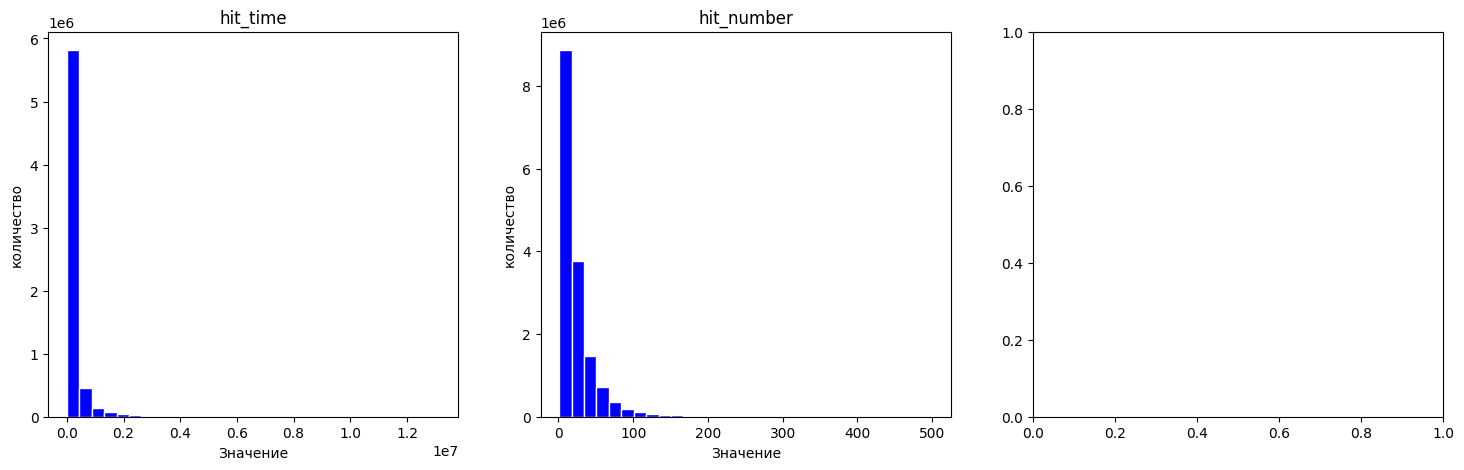

In [ ]:
num_cols = ['hit_time', 'hit_number', 'event_value']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))  # 1 строка, 3 столбца

for ax, col in zip(axes, num_cols):
    ax.hist(df_hits[col].dropna(), bins=30, color='blue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Значение')
    ax.set_ylabel('количество')

plt.tight_layout()
plt.show()

In [ ]:
df_hits.describe()

,hit_time,hit_number
count,6.566148e+06,1.572647e+07
mean,2.091050e+05,2.356715e+01
std,4.032110e+05,2.887713e+01
min,0.000000e+00,1.000000e+00
25%,2.412000e+04,7.000000e+00
50%,8.994100e+04,1.500000e+01
75%,2.195352e+05,2.900000e+01
max,1.315688e+07,5.000000e+02


Пока что hit_time,	hit_number выглядят неинформативно и с наличием выбросов, возможно после объединения талиц эти признаки начнут нести смысл.

In [ ]:
df_hits.info(max_cols=250)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 1.2+ GB


Переведем время из hit_date(object) в формат datetime и удалим старую колонку.

In [ ]:
df_hits['hit_date'] = pd.to_datetime(df_hits['hit_date'], errors='coerce')
print('Прпуски в hit_date:', df_hits['hit_date'].isna().sum())

# Создаём отдельные колонки
df_hits['hit_year'] = df_hits['hit_date'].dt.year
df_hits['hit_month'] = df_hits['hit_date'].dt.month
df_hits['hit_day'] = df_hits['hit_date'].dt.day
df_hits = df_hits.drop(columns='hit_date')
df_hits.head()

Прпуски в hit_date: 0


,session_id,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,hit_year,hit_month,hit_day
0,5639623078712724064.1640254056.1640254056,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,2021,12,23
1,7750352294969115059.1640271109.1640271109,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,2021,12,23
2,885342191847998240.1640235807.1640235807,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,2021,12,23
3,142526202120934167.1640211014.1640211014,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,2021,12,23
4,3450086108837475701.1640265078.1640265078,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,2021,12,23


In [ ]:
exclude = ['session_id']
for col in df_hits.select_dtypes(include=['object', 'category']).columns:
    if col not in exclude:
        df_hits[col] = df_hits[col].astype('category')

In [ ]:
df_hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 12 columns):
 #   Column          Dtype   
---  ------          -----   
 0   session_id      object  
 1   hit_time        float64 
 2   hit_number      int64   
 3   hit_type        category
 4   hit_referer     category
 5   hit_page_path   category
 6   event_category  category
 7   event_action    category
 8   event_label     category
 9   hit_year        int32   
 10  hit_month       int32   
 11  hit_day         int32   
dtypes: category(6), float64(1), int32(3), int64(1), object(1)
memory usage: 793.2+ MB


# **Объединение**

In [ ]:
gc.collect()

568

In [ ]:
df_merged = df_hits.merge(df_session, on='session_id', how='left', copy=False)
# df_merged = df_loaded = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/SberAuto/Sberdata.pkl')

In [ ]:
df_merged.head(15)

,session_id,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,hit_year,...,geo_city,sess_year,sess_month,sess_day,sess_hour,sess_minute,sess_second,sess_weekday,sess_quarter,sess_dayofyear
0,5639623078712724064.1640254056.1640254056,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,2021,...,Saint Petersburg,2021.0,12.0,23.0,13.0,7.0,36.0,3.0,4.0,357.0
1,7750352294969115059.1640271109.1640271109,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,2021,...,Chelyabinsk,2021.0,12.0,23.0,17.0,51.0,49.0,3.0,4.0,357.0
2,885342191847998240.1640235807.1640235807,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,2021,...,Moscow,2021.0,12.0,23.0,8.0,3.0,27.0,3.0,4.0,357.0
3,142526202120934167.1640211014.1640211014,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,2021,...,Podolsk,2021.0,12.0,23.0,1.0,10.0,14.0,3.0,4.0,357.0
4,3450086108837475701.1640265078.1640265078,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,2021,...,Tallinn,2021.0,12.0,23.0,16.0,11.0,18.0,3.0,4.0,357.0
5,6466333295973247896.1640246168.1640246168,704194.0,41,event,NaN,sberauto.com/cars?utm_source_initial=youtube&u...,quiz,quiz_show,NaN,2021,...,Moscow,2021.0,12.0,23.0,10.0,56.0,8.0,3.0,4.0,357.0
6,281215510786615563.1640245516.1640245516,911854.0,102,event,NaN,sberauto.com/cars/toyota?isnew=false&rental_ca...,quiz,quiz_show,NaN,2021,...,Vladivostok,2021.0,12.0,23.0,10.0,45.0,16.0,3.0,4.0,357.0
7,4024492994895054107.1640269084.1640269084,1071804.0,85,event,NaN,sberauto.com/cars/all/mercedes-benz/glc/f8f330...,quiz,quiz_show,NaN,2021,...,Ulyanovsk,2021.0,12.0,23.0,17.0,18.0,4.0,3.0,4.0,357.0
8,555009234841130092.1640256620.1640256620,1013899.0,101,event,VloVXNWduHeTjUoDkjkO,sberauto.com/cars/all/kia/sorento/c38179cb?utm...,quiz,quiz_show,NaN,2021,...,Saint Petersburg,2021.0,12.0,23.0,13.0,50.0,20.0,3.0,4.0,357.0
9,2692901778487480807.1640206845.1640206845,0.0,1,event,NaN,sberauto.com/cars/all/nissan/x-trail/0744675f?...,card_web,view_card,NaN,2021,...,Moscow,2021.0,12.0,23.0,0.0,0.0,45.0,3.0,4.0,357.0


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 36 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   session_id                object  
 1   hit_time                  float64 
 2   hit_number                int64   
 3   hit_type                  category
 4   hit_referer               category
 5   hit_page_path             category
 6   event_category            category
 7   event_action              category
 8   event_label               category
 9   hit_year                  int32   
 10  hit_month                 int32   
 11  hit_day                   int32   
 12  client_id                 object  
 13  visit_number              float64 
 14  utm_source                category
 15  utm_medium                category
 16  utm_campaign              category
 17  utm_adcontent             category
 18  utm_keyword               category
 19  device_category           category
 20  

In [ ]:
df_merged.to_pickle('Sberdata_do_encoder.pkl')

In [ ]:
missing_count = df_merged.isnull().sum()
missing_count=missing_count[missing_count>0]

missing_df = pd.DataFrame({
  'Пропусков': missing_count,
  'Процент':(missing_count/len(df_merged)*100).round(1)
})

missing_df.sort_values('Процент', ascending=False)

,Пропусков,Процент
device_model,15604183,99.2
hit_time,9160322,58.2
hit_referer,6274804,39.9
event_label,3760184,23.9
device_brand,1548395,9.8
device_os,1128712,7.2
utm_keyword,416414,2.6
utm_adcontent,372051,2.4
utm_campaign,65030,0.4
utm_medium,41251,0.3


In [ ]:
df_merged = df_merged.drop(columns='device_model')

In [ ]:
for col in ['device_os',	'hit_time', 'hit_referer', 'device_brand', 'event_label'
]:
    if df_merged[col].notna().any():
        df_merged[col] = df_merged[col].fillna(df_merged[col].mode()[0])
    else:
        # если все NaN, подставляем запасное значение
        df_merged[col] = df_merged[col].fillna('Unknown' if df_merged[col].dtype == 'object' or
                                               df_merged[col].dtype == 'category' else 0)

In [ ]:
from sklearn.impute import SimpleImputer

# Выбираем колонки, которые нужно заполнить (можно все или указанные)
cols_to_fill = ['utm_keyword', 'utm_adcontent', 'utm_campaign', 'client_id',
                'visit_number', 'utm_medium', 'utm_source', 'device_category',
                'device_screen_resolution', 'device_browser', 'geo_country',
                'geo_city', 'sess_year', 'sess_month', 'sess_day', 'sess_hour',
                'sess_minute', 'sess_second', 'sess_weekday', 'sess_quarter',
                'sess_dayofyear']

# Создаём импьютер с модой
imputer = SimpleImputer(strategy='most_frequent')
df_merged[cols_to_fill] = imputer.fit_transform(df_merged[cols_to_fill])

In [ ]:
missing_count = df_merged.isnull().sum()
missing_count=missing_count[missing_count>0]

missing_df = pd.DataFrame({
  'Пропусков': missing_count,
  'Процент':(missing_count/len(df_merged)*100).round(1)
})

missing_df.sort_values('Процент', ascending=False)

,Пропусков,Процент


МОжно было бы попробовать заполнить пропуски на основе данных из полных колонок, но увы, мне выдает ошибку по нехватке ОЗУ

```python
lower_miss = [
    'device_category',
    'device_screen_resolution',
    'device_browser',
    'geo_country',
    'geo_city'
]

for col in lower_miss:
    if df_session[col].notna().any():
        mode_val = df_session[col].mode()[0]
        df_session[col] = df_session[col].fillna(mode_val)
    else:
        if pd.api.types.is_numeric_dtype(df_session[col]):
            df_session[col] = df_session[col].fillna(0)
        else:
            df_session[col] = df_session[col].fillna('Unknown')

# Вычисляем моду для device_os внутри каждой группы
known_os = df_session[df_session['device_os'].notna()]
mode_dict_os = known_os.groupby(lower_miss)['device_os'].agg(
    lambda x: x.value_counts().idxmax()
).to_dict()

missing_os = df_session['device_os'].isna()
if missing_os.any():
    # Создаём временный ключ группы
    df_session['_group_key'] = df_session[lower_miss].apply(tuple, axis=1)
    chunk_size = 50000
    for start in range(0, len(df_session), chunk_size):
        end = start + chunk_size
        chunk = df_session.iloc[start:end]
        mask_chunk = chunk['device_os'].isna()
        if mask_chunk.any():
            chunk.loc[mask_chunk, 'device_os'] = chunk.loc[mask_chunk, '_group_key'].map(mode_dict_os)
        df_session.loc[chunk.index, 'device_os'] = chunk['device_os']
    df_session.drop(columns=['_group_key'], inplace=True)

if df_session['device_os'].notna().any():
    global_mode_os = df_session['device_os'].mode()[0]
else:
    global_mode_os = 'Unknown'
df_session['device_os'] = df_session['device_os'].fillna(global_mode_os)
```

# **Кодирование признаков**

In [ ]:
pip install category_encoders scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from category_encoders import HashingEncoder

# Определяем категориальные колонки (тип object или category)
cat_cols = df_merged.select_dtypes(include=['object', 'category']).columns.tolist()
exclude_cols = ['session_id', 'client_id']

df_label = df_merged.copy()
df_hashed = df_merged.copy()

for col in exclude_cols:
    # Заполняем пропуски строкой 'unknown'
    df_label[col] = df_label[col].fillna('unknown').astype(str)
    df_hashed[col] = df_hashed[col].fillna('unknown').astype(str)

target = ['event_action']
cat_cols_to_encode = [col for col in cat_cols if col not in target]

# Label Encoding (для бустинга) с помощью OrdinalEncoder
if cat_cols_to_encode:
    ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    # Применяем ко всем категориальным колонкам сразу
    encoded_array = ordinal_enc.fit_transform(df_label[cat_cols_to_encode])
    # Заменяем исходные колонки на закодированные значения
    df_label[cat_cols_to_encode] = encoded_array.astype(int)  # приводим к int для единообразия

# Hashing Encoding (для регрессий) с помощью HashingEncoder
if cat_cols_to_encode:
    n_components = 10
    hasher = HashingEncoder(cols=cat_cols_to_encode, n_components=n_components, return_df=True)
    df_hashed = hasher.fit_transform(df_hashed)

# Итоговые датафреймы:
# df_label – с Label Encoding для бустинга
# df_hashed – с Hashing Encoding для регрессий

NameError: name 'df_merged' is not defined

In [ ]:
print("df_label shape:", df_label.shape)
print("\ndf_hashed shape:", df_hashed.shape)

NameError: name 'df_label' is not defined

In [ ]:
df_label.to_pickle('Sberdata_label_encoder.pkl')

NameError: name 'df_label' is not defined

In [ ]:
df_label.head()

,session_id,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,hit_year,...,geo_city,sess_year,sess_month,sess_day,sess_hour,sess_minute,sess_second,sess_weekday,sess_quarter,sess_dayofyear
0,968651,597864.0,30,0,5513,318148,41,quiz_show,8121,2021,...,1811,0,7,22,13,7,36,3,2,217
1,1410179,597331.0,41,0,5513,278047,41,quiz_show,8121,2021,...,429,0,7,22,17,51,49,3,2,217
2,1640490,796252.0,49,0,5513,239986,41,quiz_show,8121,2021,...,1346,0,7,22,8,3,27,3,2,217
3,88126,934292.0,46,0,5513,328568,41,quiz_show,8121,2021,...,1652,0,7,22,1,10,14,3,2,217
4,510846,768741.0,79,0,5513,183191,41,quiz_show,8121,2021,...,2062,0,7,22,16,11,18,3,2,217


In [ ]:
df_hashed.to_pickle('Sberdata_hashed_encoder.pkl')

In [ ]:
df_hashed.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,hit_time,hit_number,event_action,hit_year,hit_month,hit_day
0,2,2,3,2,4,6,1,0,4,5,597864.0,30,quiz_show,2021,12,23
1,3,2,5,1,4,4,1,1,4,4,597331.0,41,quiz_show,2021,12,23
2,4,2,4,1,2,5,1,1,4,5,796252.0,49,quiz_show,2021,12,23
3,2,2,3,2,2,7,1,2,5,3,934292.0,46,quiz_show,2021,12,23
4,3,1,7,3,3,3,0,1,3,5,768741.0,79,quiz_show,2021,12,23


# Загрузка df и обучение

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import xgboost as xgb
import joblib
import os
import pickle

In [ ]:
file_path = "Sberdata_hashed_encoder.pkl"
with open(file_path, "rb") as f:
    df_hashed = pickle.load(f)

In [ ]:
with open("Sberdata_label_encoder.pkl", "rb") as f:
    df_label = pickle.load(f)

In [ ]:
pip install scikit-optimize lightgbm xgboost scikit-learn

In [ ]:
from skopt import BayesSearchCV, gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
from skopt.plots import plot_convergence

import warnings
warnings.filterwarnings('ignore')

In [ ]:
target_col = 'event_action'


X_label = df_label.drop(columns=[target_col])
y = df_label[target_col]

# Оставляем только классы, которых >= 2
counts = y.value_counts()
valid_classes = counts[counts >= 2].index
mask = y.isin(valid_classes)
X_label_filtered = X_label[mask]
y_filtered = y[mask]

X_label_train, X_label_test, y_train, y_test = train_test_split(
    X_label_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)



In [ ]:
X_hashed = df_hashed.drop(columns=[target_col])
X_label = df_label.drop(columns=[target_col])

counts = y.value_counts()
valid_classes = counts[counts >= 2].index
mask = y.isin(valid_classes)

X_hashed_filtered = X_hashed[mask]
X_label_filtered = X_label[mask]
y_filtered = y[mask]

X_hashed_train, X_hashed_test, y_train, y_test = train_test_split(
    X_hashed_filtered, y_filtered, test_size=0.2, random_state=42
)
X_label_train, X_label_test, y_h_train, y_h_test = train_test_split(
    X_label_filtered, y_filtered, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

# Общие настройки для всех моделей
N_ITER = 15  # число итераций поиска
CV_FOLDS = 3 # число фолдов для кросс-валидации
RANDOM_STATE = 42

# Стратифицированная кросс-валидация
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

## **LightGBM на df_label**

In [ ]:
print("Распределение в y_train:", y_train.value_counts())
print("Распределение в y_test:", y_test.value_counts())

Распределение в y_train: event_action
view_card                     2846862
view_new_card                 2841550
sub_landing                   1438570
go_to_car_card                 779794
sub_view_cars_click            632717
                               ...   
rating_banner_show                  0
new_year_road_help_btn              0
show_pos_status_declined            0
titul_page_view                     0
survey_buy_after_sell_when          0
Name: count, Length: 230, dtype: int64
Распределение в y_test: event_action
view_card                        712123
view_new_card                    709459
sub_landing                      359547
go_to_car_card                   193872
sub_view_cars_click              158798
                                  ...  
show_popup_error_confirmation         0
show_pos_status_declined              0
titul_page_view                       0
survey_buy_after_sell_start           0
survey_buy_after_sell_when            0
Name: count, Length: 230, dt

In [ ]:
from sklearn.preprocessing import LabelEncoder
# 1. Определяем целевую переменную
target_col = 'event_action'   # или как у вас называется

# 2. Задаём порог частоты (например, класс должен встречаться >= 5000 раз)
MIN_FREQ = 5000

# 3. Считаем частоты классов в исходных данных (до разбиения)
freq = y.value_counts()
rare_classes = freq[freq < MIN_FREQ].index.tolist()

# 4. Создаём новую целевую переменную с объединением редких классов
y_clean = y.copy()
y_clean = y_clean.replace(rare_classes, 'other')

# 5. Проверяем количество уникальных классов
print("Количество классов после объединения:", y_clean.nunique())
print("Распределение:\n", y_clean.value_counts())

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_clean)
n_classes = len(label_encoder.classes_)
print(f"Число классов: {n_classes}")

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Маппинг классов:", class_mapping)


Количество классов после объединения: 77
Распределение:
 event_action
view_card                  3558985
view_new_card              3551009
sub_landing                1798117
go_to_car_card              973666
sub_view_cars_click         791515
                            ...   
auto_subscription_click       5939
typing_in_leasing_chat        5597
view_used_card                5304
surname_entered               5154
sber_id_auth_start            5027
Name: count, Length: 77, dtype: int64
Число классов: 77
Маппинг классов: {'analystlabel': np.int64(0), 'auto_subscription_click': np.int64(1), 'click_on_confirm_sms_code': np.int64(2), 'click_on_get_code': np.int64(3), 'click_on_logo': np.int64(4), 'click_on_menu': np.int64(5), 'click_on_subscription': np.int64(6), 'code_sms_entered_success': np.int64(7), 'go_to_car_card': np.int64(8), 'go_to_offer': np.int64(9), 'go_to_terms': np.int64(10), 'greenday_get_gift': np.int64(11), 'listing_ads_sort': np.int64(12), 'name_entered': np.int64(13), 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform
import lightgbm as lgb

param_dist_lgb = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 9),
    'learning_rate': loguniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': loguniform(1e-4, 10.0),
    'reg_lambda': loguniform(1e-4, 10.0),
    'min_child_samples': randint(5, 20)
}

random_search_lgb = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(
        objective='multiclass',
        num_class=n_classes,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
    param_distributions=param_dist_lgb,
    n_iter=20,
    cv=2,
    scoring='roc_auc_ovr',
    n_jobs=1,
    random_state=42,
    verbose=0
)

random_search_lgb.fit(X_label_train, y_train)
print("Лучшие параметры:", random_search_lgb.best_params_)
print("Лучший ROC-AUC (CV):", random_search_lgb.best_score_)

# **XGBoost на df_label**

In [ ]:
param_space_xgb = {
    'n_estimators': Integer(100, 1000),
    'max_depth': Integer(3, 12),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'reg_alpha': Real(1e-8, 10.0, prior='log-uniform'),
    'reg_lambda': Real(1e-8, 10.0, prior='log-uniform'),
    'min_child_weight': Integer(1, 10),
}

model_xgb = xgb.XGBClassifier(objective='multi:softprob', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

bayes_search_xgb_label = BayesSearchCV(
    estimator=model_xgb,
    search_spaces=param_space_xgb,
    n_iter=N_ITER,
    cv=cv,
    scoring='roc_auc_ovr',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

bayes_search_xgb_label.fit(X_label_train, y_train)

print(f"Лучшие параметры XGBoost (df_label): {bayes_search_xgb_label.best_params_}")
print(f"Лучший ROC-AUC (CV): {bayes_search_xgb_label.best_score_:.4f}")

# **Logistic Regression на df_hashed**

In [ ]:
param_space_lr = {
    'C': Real(1e-4, 1e2, prior='log-uniform'),
    'max_iter': Integer(100, 1000)
}

model_lr = LogisticRegression(class_weight='balanced', solver='lbfgs' random_state=RANDOM_STATE)

bayes_search_lr_hashed = BayesSearchCV(
    estimator=model_lr,
    search_spaces=param_space_lr,
    n_iter=N_ITER,
    cv=cv,
    scoring='roc_auc_ovr',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

bayes_search_lr_hashed.fit(X_hashed_train_scaled, y_train)

print(f"Лучшие параметры LogisticRegression (df_hashed): {bayes_search_lr_hashed.best_params_}")
print(f"Лучший ROC-AUC (CV): {bayes_search_lr_hashed.best_score_:.4f}")

# **LightGBM на df_hashed**

In [ ]:
bayes_search_lgb_hashed = BayesSearchCV(
    estimator=lgb.LGBMClassifier(objective='multiclass', random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
    search_spaces=param_space_lgb,   # используем то же пространство, что и для первого LGB
    n_iter=N_ITER,
    cv=cv,
    scoring='roc_auc_ovr',
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=0
)

bayes_search_lgb_hashed.fit(X_hashed_train, y_train)

print(f"Лучшие параметры LightGBM (df_hashed): {bayes_search_lgb_hashed.best_params_}")
print(f"Лучший ROC-AUC (CV): {bayes_search_lgb_hashed.best_score_:.4f}")